<a href="https://colab.research.google.com/github/fleqi/proyecto-mineria/blob/colab/hito1/notebooks/datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA Hito 1

---



In [1058]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
DATA = Path("/content/proyecto-mineria/hito1/data")

---

## CONAF



Para empezar el análisis exploratorio, podemos fijarnos en los datos de la CONAF, que si bien son poco específicos, al tener los datos agregados por temporada permiten entender mejor las estadísticas.

In [1059]:
CONAF = DATA / "conaf"

In [1060]:
f1 = CONAF / "1.- Ocurrencia y Daño Histórico Nacional, 1985 - 2024_octubre.xls"
df1 = pd.read_excel(f1, sheet_name="Historico", header=7)
df1 = df1.iloc[2:, 2:7]
df1 = df1.dropna()
df1.columns = "Año", "denominacion", "n_incendios", "superficie_ha", "superficie_prom_ha"
df1["Año"] = df1["Año"].str.slice(0, 4).astype(int)
df1.head()

,Año,denominacion,n_incendios,superficie_ha,superficie_prom_ha
2,1963,64.0,435.0,19600.0,45.057471
3,1964,65.0,269.0,17200.0,63.940520
4,1965,66.0,396.0,19900.0,50.252525
5,1966,67.0,307.0,15820.0,51.530945
6,1967,68.0,507.0,61314.0,120.934911


In [1061]:
df1.describe()

,Año,denominacion,n_incendios,superficie_ha,superficie_prom_ha
count,61.000000,61.000000,61.000000,61.000000,61.000000
mean,1993.000000,53.016393,4641.262295,65912.350987,19.801051
std,17.752934,35.695701,2257.375740,86948.685625,23.609790
min,1963.000000,0.000000,269.000000,9604.000000,2.031436
25%,1978.000000,15.000000,3380.000000,25545.000000,7.569701
50%,1993.000000,69.000000,5252.000000,43592.000000,11.090759
75%,2008.000000,84.000000,6214.000000,80064.190000,16.789704
max,2023.000000,99.000000,8127.000000,570197.394200,120.934911


<Axes: title={'center': 'Cantidad de incendios por año en Chile'}, xlabel='Año', ylabel='Cantidad de incendios'>

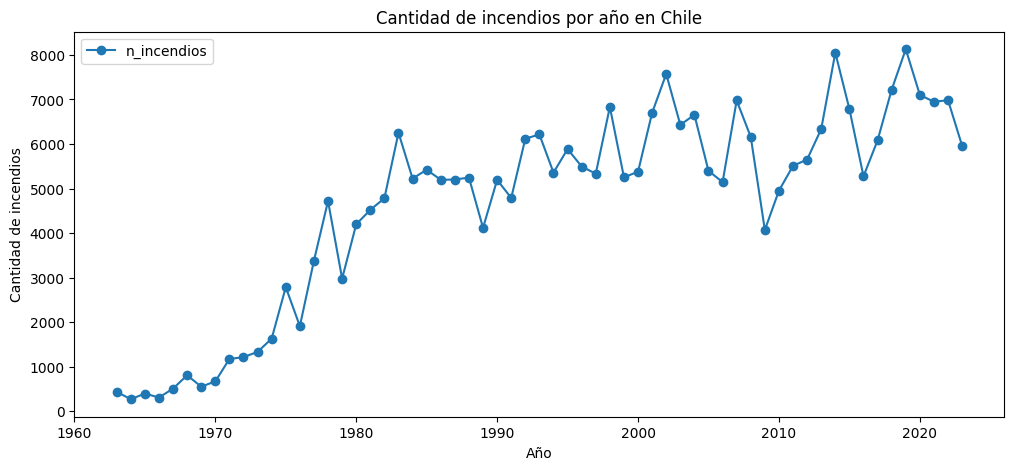

In [1062]:
df1.plot.line(x = 'Año', y = 'n_incendios', marker = 'o', figsize = (12,5), title = "Cantidad de incendios por año en Chile", ylabel = "Cantidad de incendios")

Con este gráfico podemos plantearnos si los últimos años de cambio climático tienen influencia sobre la cantidad de incendios anuales.

<Axes: title={'center': 'Superficie quemada media al año en Chile'}, xlabel='Año', ylabel='Superficie quemada media (ha)'>

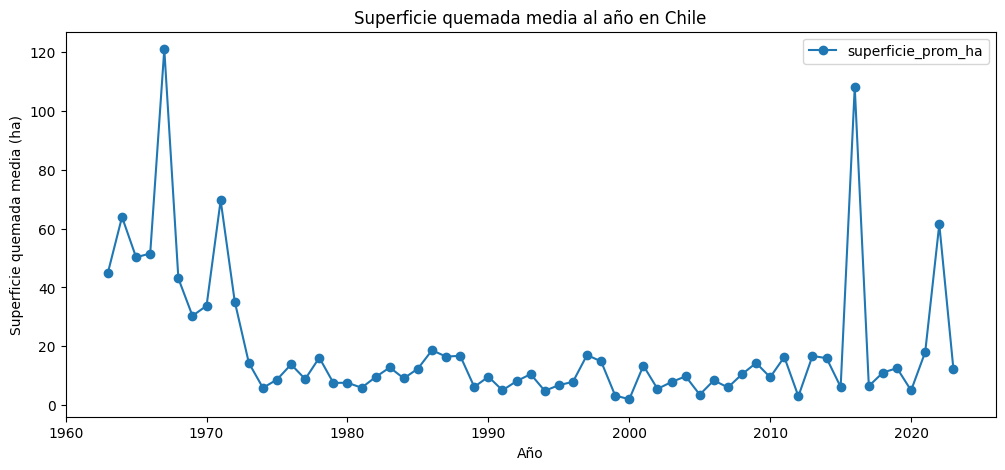

In [1063]:
df1.plot.line(x = 'Año', y = 'superficie_prom_ha', marker = 'o', figsize = (12,5), title = "Superficie quemada media al año en Chile", ylabel = "Superficie quemada media (ha)")

Se nota una clara bajada en la superficie quemada con los años, que se podría atribuir a mejores tecnologías para combatir incendios, sin embargo, en los últimos años se ha evidenciado una subida que se podría atribuir a múltiples causas como la cantidad de incendios contra la capacidad de respuesta o las condiciones climáticas y la influencia que tienen sobre la proliferación de estos.

Queda en duda si es que estos daños podrían reducirse teniendo conocimiento de las condiciones climáticas.

In [1064]:
f8 = CONAF / "8.- Distribución Nacional de la Ocurrencia (N°) de Incendios Forestales según Causalidad, 2003 - 2024_octubre.xls"
# aqui me tuvo que ayudar claude porque la distribucion del excel estaba demasiado rara como para trabajarla en menos de 2 horas
raw = pd.read_excel(f8, sheet_name="Nacional 2003-2023", header=None)

ini = raw.index[raw[0].astype(str).str.strip() == "Causas General"][0]
fin = raw.index[(raw[0].astype(str).str.strip() == "TOTAL GENERAL") & (raw.index > ini)][0]

años = raw.loc[ini, 1:21].astype(int).tolist()
causas = raw.loc[ini+1:fin, 0:21].copy()
causas.columns = ["causa"] + años
causas = causas.dropna(subset=["causa"])
causas["causa"] = causas["causa"].str.strip()

largo = causas.melt(id_vars="causa", var_name="temporada_fin", value_name="n")
largo["n"] = pd.to_numeric(largo["n"]).fillna(0)

total = largo[largo["causa"] == "TOTAL GENERAL"].set_index("temporada_fin")["n"]
largo = largo[largo["causa"] != "TOTAL GENERAL"].copy()
largo["grupo"] = (largo["causa"].str[0]
                  .map({"1": "Accidentales", "2": "Intencionales", "3": "Naturales", "4": "Desconocidas"})
                  .fillna("Sin causa"))

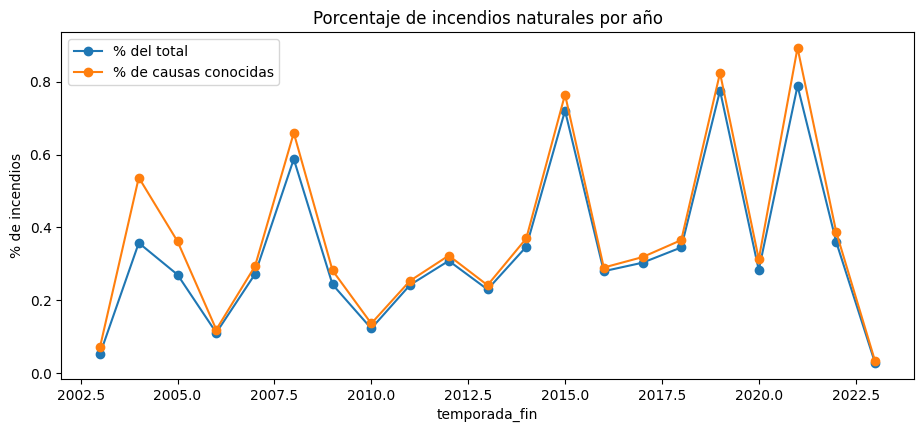

In [1065]:
def pct_grupos(grupos, solo_conocidas=False):
    g = largo.groupby(["temporada_fin", "grupo"])["n"].sum().unstack(fill_value=0)
    if solo_conocidas:
        denom = g[["Accidentales", "Intencionales", "Naturales"]].sum(axis=1)
    else:
        denom = total
    return g[list(grupos)].sum(axis=1) / denom * 100

a = pct_grupos(["Naturales"])
b = pct_grupos(["Naturales"], solo_conocidas=True)

ax = a.plot(marker="o", figsize=(11, 4.5), label="% del total")
b.plot(marker="o", ax=ax, label="% de causas conocidas")
ax.set_ylabel("% de incendios")
ax.set_title("Porcentaje de incendios naturales por año")
ax.legend()

---


## DMC
El DMC tiene datos meteorológicos de muchas partes, por lo que podemos usarlo para evaluar las temperaturas por cada año.

Para esto ignoraremos los datos de fuera del continente, ya que podrían inducir variaciones no deseadas y no son el foco del análisis.

### Temperatura

In [1066]:
DMC = DATA / "dmc"
TEMP = DMC / "temperatura"
TEMPMX = DMC/ "tmaxima"
TEMPMN = DMC/ "tminima"

In [1067]:
archivos = sorted((TEMP).glob("*.csv"))
temp = pd.concat((pd.read_csv(f, parse_dates=["date"]) for f in archivos), ignore_index=True)
temp=temp[~temp["CodigoNacional"].isin([270001.0, 330031.0, 950001.0])]
temp["Año"] = temp["date"].dt.year
print(temp.duplicated().sum())
print(temp.isnull().sum())

4
date                0
CodigoNacional      0
nombreEstacion      0
latitud             0
longitud            0
temp_mean         903
Año                 0
dtype: int64


Como encopntramos datos duplicados y vacios, preferimos ignorarlos.

<Axes: title={'center': 'Temperatura media anual en Chile'}, xlabel='Año', ylabel='Temperatura media (°C)'>

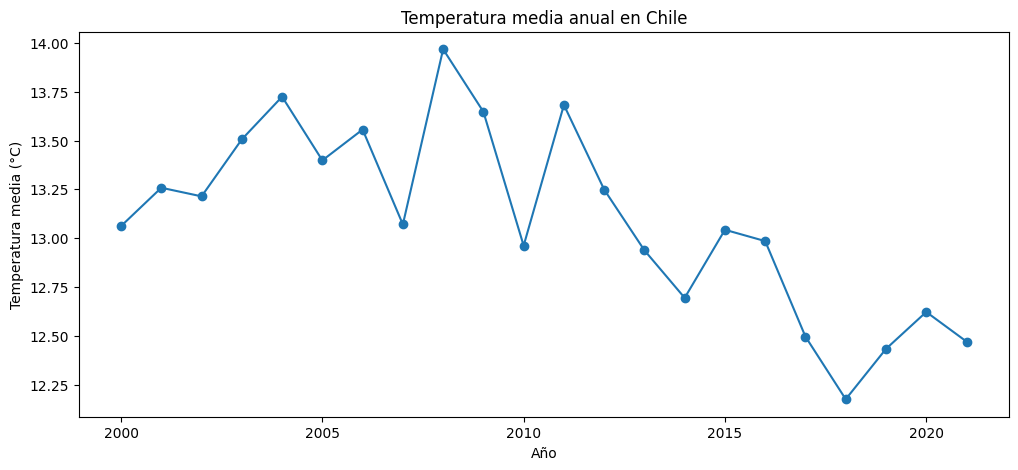

In [1068]:
temp = temp.dropna()
temp = temp.drop_duplicates()
temp = temp[temp['Año']<2022]
temp.groupby(["Año"])["temp_mean"].mean().plot.line(x = 'Año', y = 'temp_mean', marker = 'o', figsize = (12,5), ylabel = "Temperatura media (°C)", title = "Temperatura media anual en Chile")

Esto muestra una clara bajada de la temperatura, sin embargo, podemos buscar una nueva temperatura media gracias a las máximas y mínimas. Si es que faltaban valores de mediciones mínimas o máximas, estos modificarían mucho los promedios, por lo que eliminar cualquier faltante y duplicado una vez que fusionamos las tablas permite obtener valores más correctos.

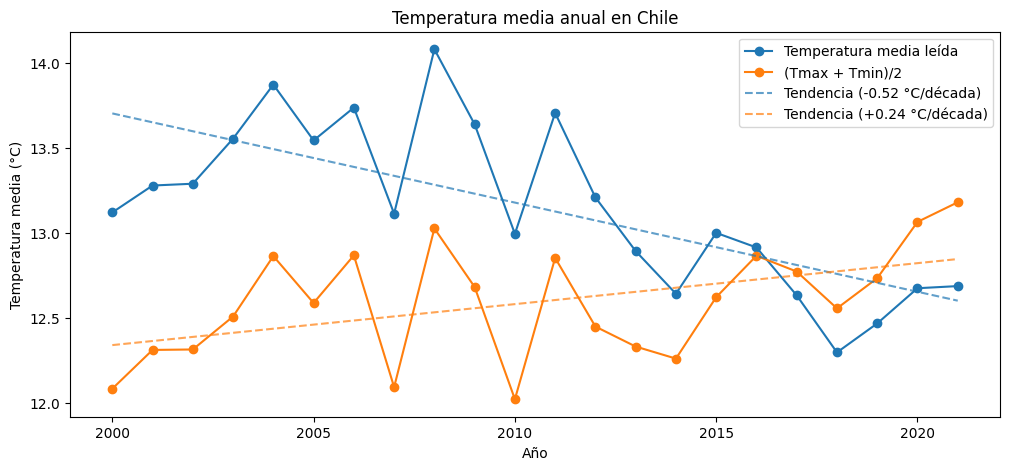

In [1069]:
archivos = sorted((TEMPMX).glob("*.csv"))
tmax = pd.concat((pd.read_csv(f, parse_dates=["date"]) for f in archivos), ignore_index=True)
archivos = sorted((TEMPMN).glob("*.csv"))
tmin = pd.concat((pd.read_csv(f, parse_dates=["date"]) for f in archivos), ignore_index=True)
temp = temp.merge(tmax[["date", "CodigoNacional", "tmax"]], on=["date", "CodigoNacional"])
temp = temp.merge(tmin[["date", "CodigoNacional", "tmin"]], on=["date", "CodigoNacional"])
temp["temp_mean_art"] = (temp["tmax"] + temp["tmin"]) / 2
temp = temp.dropna()
temp = temp.drop_duplicates()
tempmed= temp.groupby(["Año"])["temp_mean"].mean()
tempart= temp.groupby(["Año"])["temp_mean_art"].mean()
grafico = tempmed.plot.line(x = 'Año', y = 'temp_mean', marker = 'o', figsize = (12,5), ylabel = "Temperatura media (°C)", title = "Temperatura media anual en Chile", label = "Temperatura media leída")
tempart.plot.line(x = 'Año', y = 'temp_mean_art', marker = 'o', figsize = (12,5), ylabel = "Temperatura media (°C)", title = "Temperatura media anual en Chile", label = "(Tmax + Tmin)/2")
for serie, color in [(tempmed, "tab:blue"), (tempart, "tab:orange")]:
    pendiente, intercepto = np.polyfit(serie.index, serie.values, 1)
    grafico.plot(serie.index, pendiente * serie.index + intercepto,
            linestyle="--", color=color, alpha=0.7,
            label=f"Tendencia ({pendiente * 10:+.2f} °C/década)")
grafico.legend()


Como se puede ver, la temperatura en chile ha ido lentamente en subida con los años, si es que ignoramos algunas variaciones, por lo que

Para hacer un análisis por regiones, podemos basarnos en la latitud, definiendo:
- Norte: lat > -32°
- Centro: -38° < lat < -32°
- Sur: lat < -38°

<Axes: title={'center': 'Temperatura media artificial anual por zona'}, xlabel='Año', ylabel='Temperatura media (°C)'>

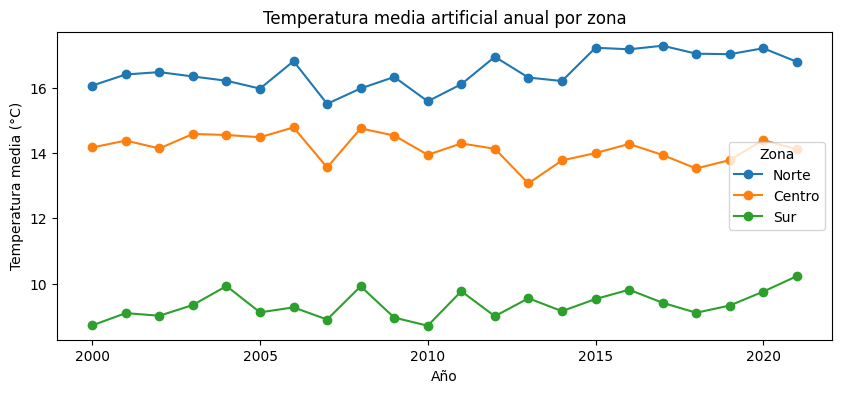

In [1070]:
temp["Zona"] = pd.cut(temp["latitud"], bins=[-90, -38, -32, 0], labels=["Sur", "Centro", "Norte"])
temp_zonas = temp.groupby(["Año", "Zona"], observed=True)["temp_mean_art"].mean().unstack()
temp_zonas[["Norte", "Centro", "Sur"]].plot(
    marker = "o",
    figsize = (10, 4),
    ylabel = "Temperatura media (°C)",
    title = "Temperatura media artificial anual por zona"
)

<Axes: title={'center': 'Temperatura media anual por zona'}, xlabel='Año', ylabel='Temperatura media (°C)'>

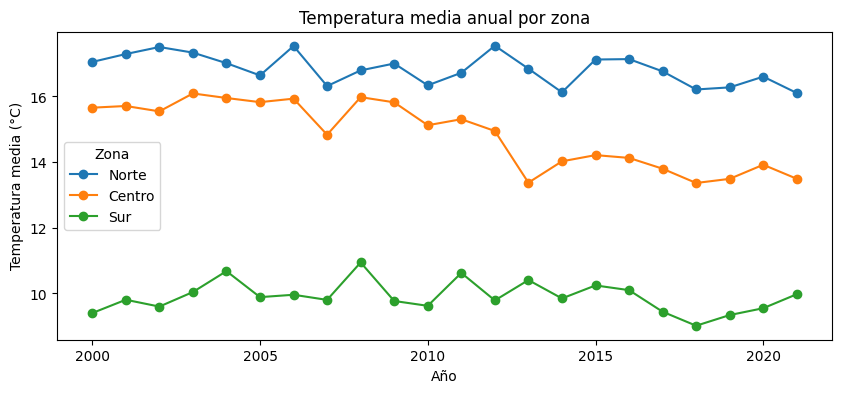

In [1071]:
temp["Zona"] = pd.cut(temp["latitud"], bins=[-90, -38, -32, 0], labels=["Sur", "Centro", "Norte"])
temp_zonas = temp.groupby(["Año", "Zona"], observed=True)["temp_mean"].mean().unstack()
temp_zonas[["Norte", "Centro", "Sur"]].plot(
    marker = "o",
    figsize = (10, 4),
    ylabel = "Temperatura media (°C)",
    title = "Temperatura media anual por zona"
)

### Humedad

In [1072]:
HUM = DMC / "humedad"
archivos = sorted((HUM).glob("*.csv"))
hum = pd.concat((pd.read_csv(f, parse_dates=["date"]) for f in archivos), ignore_index=True)
hum=hum[~hum["CodigoNacional"].isin([270001.0, 330031.0, 950001.0])]
hum = hum.dropna()
hum = hum.drop_duplicates()
hum["Año"] = hum["date"].dt.year

<Axes: title={'center': 'Humedad media anual en Chile'}, xlabel='Año', ylabel='Humedad relativa (%)'>

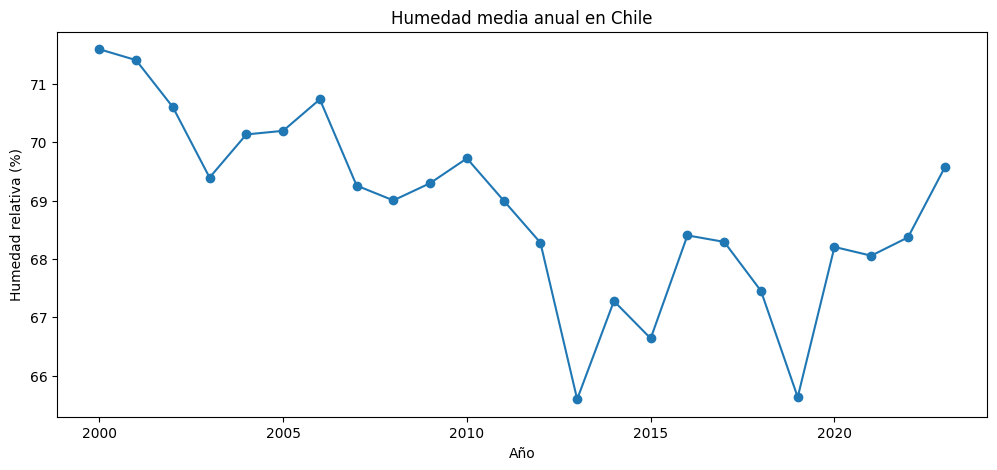

In [1073]:
hum.groupby(["Año"])["humedad_mean"].mean().plot.line(x = 'Año', y = 'humedad_mean', marker = 'o', figsize = (12,5), title = "Humedad media anual en Chile", ylabel = "Humedad relativa (%)")

<Axes: title={'center': 'Humedad media anual por zona'}, xlabel='Año', ylabel='Humedad relativa (%)'>

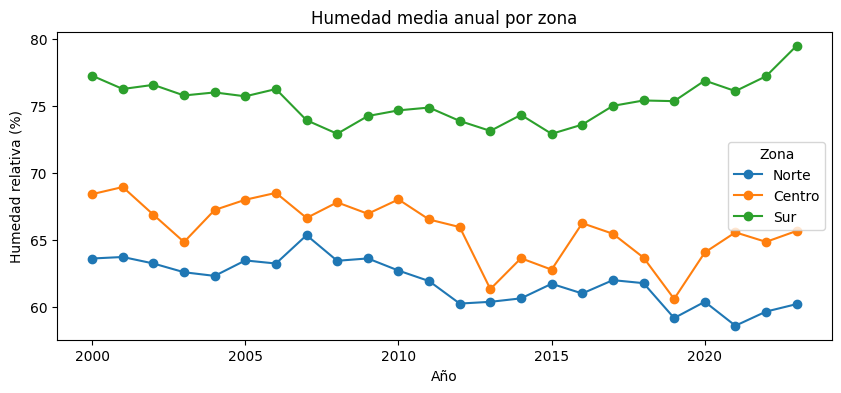

In [1074]:
hum["Zona"] = pd.cut(hum["latitud"], bins=[-90, -38, -32, 0], labels=["Sur", "Centro", "Norte"])
hum_zonas = hum.groupby(["Año", "Zona"], observed=True)["humedad_mean"].mean().unstack()
hum_zonas[["Norte", "Centro", "Sur"]].plot(
    marker = "o",
    figsize = (10, 4),
    ylabel = "Humedad relativa (%)",
    title = "Humedad media anual por zona"
)

### Viento

In [1075]:
VIENTO = DMC / "viento"
archivos = sorted((VIENTO).glob("*.csv"))
viento = pd.concat((pd.read_csv(f, parse_dates=["date"]) for f in archivos), ignore_index=True)
viento=viento[~viento["CodigoNacional"].isin([270001.0, 330031.0, 950001.0])]
viento = viento.dropna()
viento = viento.drop_duplicates()
viento["Año"] = viento["date"].dt.year

<Axes: title={'center': 'Vientos promedio y máximos anuales en Chile'}, xlabel='Año', ylabel='Viento'>

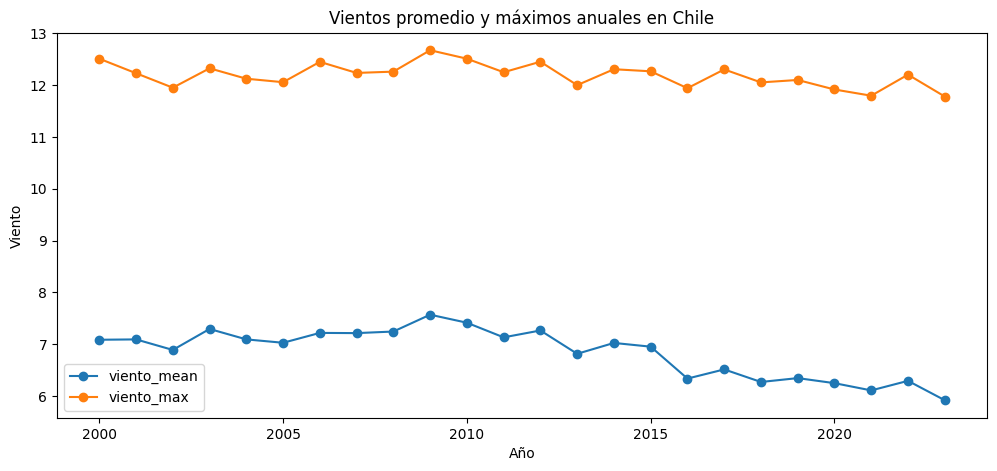

In [1076]:
vientos = viento.groupby("Año")[["viento_mean", "viento_max"]].mean()
vientos.plot( marker = "o", figsize = (12, 5), ylabel = "Viento", title = "Vientos promedio y máximos anuales en Chile")

<Axes: title={'center': 'Viento medio anual por zona'}, xlabel='Año', ylabel='Viento'>

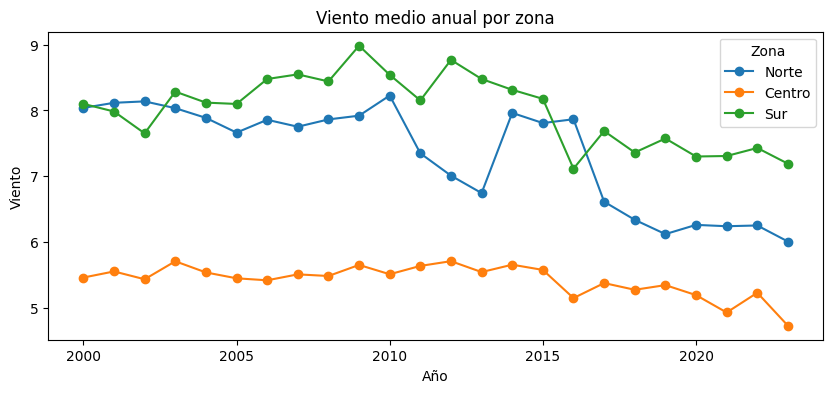

In [1077]:
viento["Zona"] = pd.cut(viento["latitud"], bins=[-90, -38, -32, 0], labels=["Sur", "Centro", "Norte"])
viento_zonas = viento.groupby(["Año", "Zona"], observed=True)["viento_mean"].mean().unstack()
viento_zonas[["Norte", "Centro", "Sur"]].plot(
    marker = "o",
    figsize = (10, 4),
    ylabel = "Viento",
    title = "Viento medio anual por zona"
)

<Axes: title={'center': 'Viento máximo medio anual por zona'}, xlabel='Año', ylabel='Viento'>

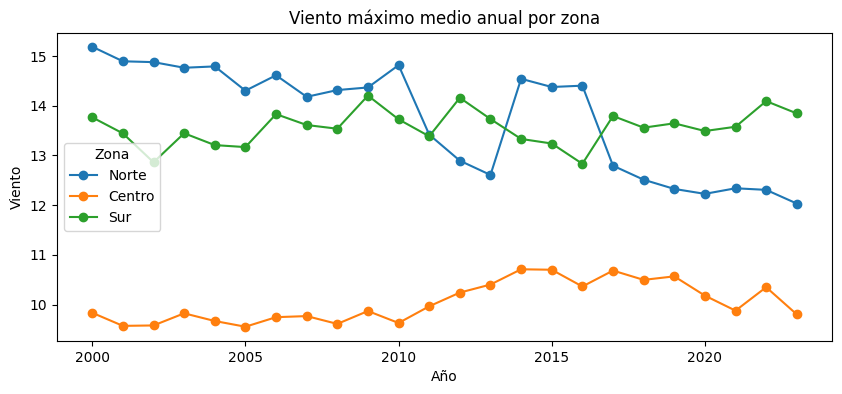

In [1078]:
viento["Zona"] = pd.cut(viento["latitud"], bins=[-90, -38, -32, 0], labels=["Sur", "Centro", "Norte"])
viento_zonas = viento.groupby(["Año", "Zona"], observed=True)["viento_max"].mean().unstack()
viento_zonas[["Norte", "Centro", "Sur"]].plot(
    marker = "o",
    figsize = (10, 4),
    ylabel = "Viento",
    title = "Viento máximo medio anual por zona"
)

#### Precipitaciones

In [1079]:
LLUVIA = DMC / "precip_24h"
archivos = sorted((LLUVIA).glob("*.csv"))
rain = pd.concat((pd.read_csv(f, parse_dates=["date"]) for f in archivos), ignore_index=True)
rain=rain[~rain["CodigoNacional"].isin([270001.0, 330031.0, 950001.0])]
rain = rain.dropna()
rain = rain.drop_duplicates()
rain["Año"] = rain["date"].dt.year.astype(int)
rain.head()

,CodigoNacional,nombreEstacion,latitud,longitud,date,precip_mm_dia,Año
0,180005.0,"Chacalluta, Arica Ap.",-18.35555,-70.34028,2000-01-02,0.0,2000
1,180005.0,"Chacalluta, Arica Ap.",-18.35555,-70.34028,2000-01-03,0.0,2000
2,180005.0,"Chacalluta, Arica Ap.",-18.35555,-70.34028,2000-01-04,0.0,2000
3,180005.0,"Chacalluta, Arica Ap.",-18.35555,-70.34028,2000-01-05,0.0,2000
4,180005.0,"Chacalluta, Arica Ap.",-18.35555,-70.34028,2000-01-06,0.0,2000


<Axes: title={'center': 'Precipitaciones diarias promedio por año en Chile'}, xlabel='Año', ylabel='Precipitaciones (mm/dia)'>

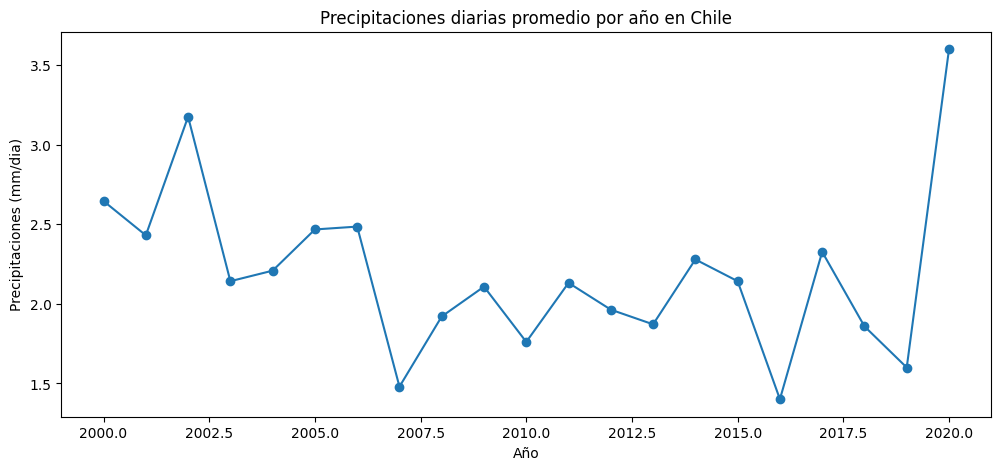

In [1080]:
rains = rain.groupby("Año")["precip_mm_dia"].mean()
rains.plot(x = "Año", y = "precip_mm_dia", marker = "o", figsize = (12, 5), ylabel = "Precipitaciones (mm/dia)", title = "Precipitaciones diarias promedio por año en Chile")

<Axes: title={'center': 'Precipitación diaria promedio anual por zona'}, xlabel='Año', ylabel='Precipitación (mm/dia)'>

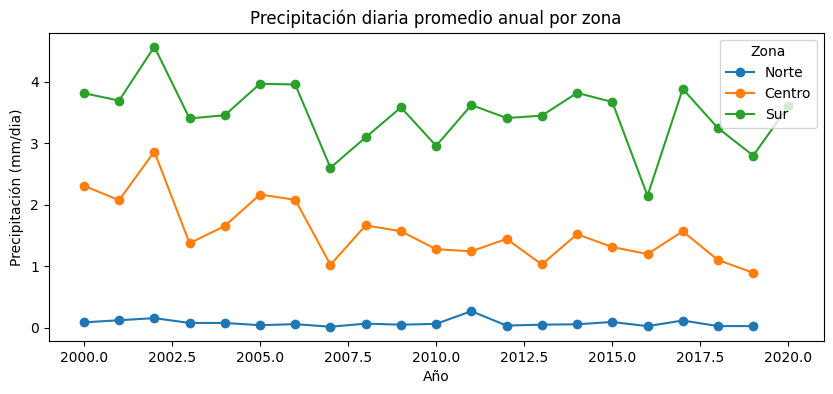

In [1081]:
rain["Zona"] = pd.cut(rain["latitud"], bins=[-90, -38, -32, 0], labels=["Sur", "Centro", "Norte"])
rain_zonas = rain.groupby(["Año", "Zona"], observed=True)["precip_mm_dia"].mean().unstack()
rain_zonas[["Norte", "Centro", "Sur"]].plot(
    marker = "o",
    figsize = (10, 4),
    ylabel = "Precipitación (mm/dia)",
    title = "Precipitación diaria promedio anual por zona"
)

#### Fusion!!
¿Qué pasa si queremos ver como se relacionan estas tablas entre si? Para esto podemos fusionarlas y graficar a la vez.

In [1082]:
temp = temp.merge(hum[["date", "CodigoNacional", "humedad_mean"]], on=["date", "CodigoNacional"])
temp = temp.merge(viento[["date", "CodigoNacional", "viento_mean", "viento_max"]], on=["date", "CodigoNacional"])
temp = temp.merge(rain[["date", "CodigoNacional", "precip_mm_dia"]], on=["date", "CodigoNacional"])
temp = temp.drop(columns=["date", "latitud", "longitud", "CodigoNacional", "nombreEstacion", "Zona"])
temp = temp.merge(df1[["Año", "n_incendios", "superficie_prom_ha"]], on=["Año"])
temp = temp[temp['Año']>=2000]
temp = temp[temp['Año']<2020]
temp = temp.dropna()
temp = temp.drop_duplicates()
df1 = df1[df1['Año']>=2000]
df1 = df1[df1['Año']<2020]
temp.head()

,temp_mean,Año,tmax,tmin,temp_mean_art,humedad_mean,viento_mean,viento_max,precip_mm_dia,n_incendios,superficie_prom_ha
0,21.541667,2000,25.4,19.8,22.60,75.000000,7.000000,18.0,0.0,5376.0,2.031436
1,20.637500,2000,23.8,17.5,20.65,66.291667,6.208333,12.0,0.0,5376.0,2.031436
2,21.150000,2000,24.8,3.5,14.15,34.000000,15.900000,33.0,0.0,5376.0,2.031436
3,16.338889,2000,19.4,11.6,15.50,77.111111,5.888889,10.0,0.0,5376.0,2.031436
4,16.253846,2000,18.6,10.0,14.30,71.384615,8.846154,14.0,0.0,5376.0,2.031436


In [1116]:
variables = {
    "temp_mean_art": "(Tmax + Tmin) / 2 (°C)",
    "humedad_mean":  "Humedad relativa (%)",
    "precip_mm_dia": "Precipitación (mm/día)",
}
variables2 = {
    "humedad_mean":  "Humedad relativa (%)",
    "viento_mean":   "Viento medio",
    "precip_mm_dia": "Precipitación (mm/día)",
}

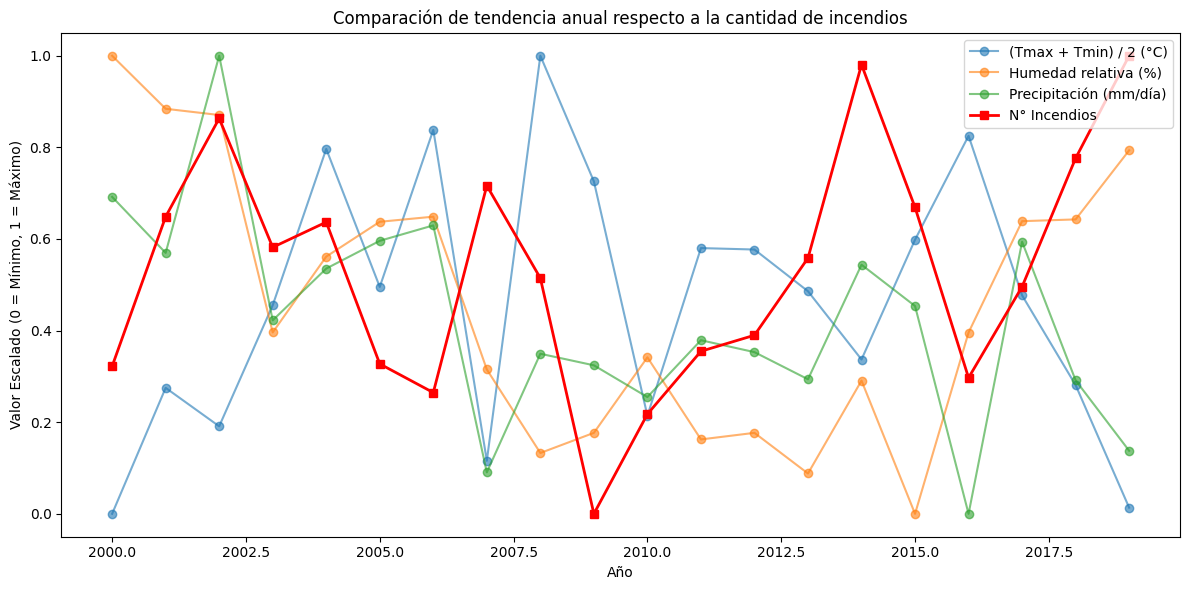

In [1115]:
import matplotlib.pyplot as plt

columnas_clima = list(variables.keys())
anual = temp.groupby("Año")[columnas_clima + ["n_incendios"]].mean()

anual_norm = (anual - anual.min()) / (anual.max() - anual.min())

fig, ax = plt.subplots(figsize=(12, 6))

for col, titulo in variables.items():
    ax.plot(anual_norm.index, anual_norm[col], marker="o", label=titulo, alpha=0.6, linewidth=1.5)

ax.plot(
    anual_norm.index,
    anual_norm["n_incendios"],
    marker="s",
    color="red",
    linewidth=2,
    label="N° Incendios"
)

ax.set_title("Comparación de tendencia anual respecto a la cantidad de incendios")
ax.set_xlabel("Año")
ax.set_ylabel("Valor Escalado (0 = Mínimo, 1 = Máximo)")
ax.legend()

plt.tight_layout()
plt.show()

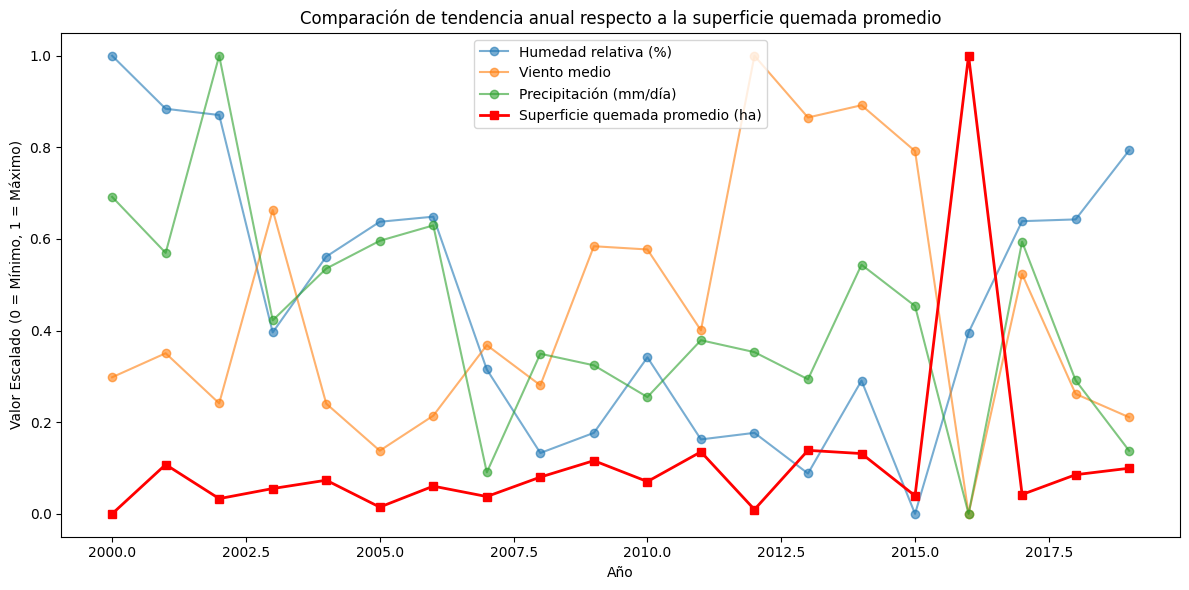

In [1117]:
import matplotlib.pyplot as plt

columnas_clima = list(variables2.keys())
anual = temp.groupby("Año")[columnas_clima + ["superficie_prom_ha"]].mean()

anual_norm = (anual - anual.min()) / (anual.max() - anual.min())

fig, ax = plt.subplots(figsize=(12, 6))

for col, titulo in variables2.items():
    ax.plot(anual_norm.index, anual_norm[col], marker="o", label=titulo, alpha=0.6, linewidth=1.5)

ax.plot(
    anual_norm.index,
    anual_norm["superficie_prom_ha"],
    marker="s",
    color="red",
    linewidth=2,
    label="Superficie quemada promedio (ha)"
)

ax.set_title("Comparación de tendencia anual respecto a la superficie quemada promedio")
ax.set_xlabel("Año")
ax.set_ylabel("Valor Escalado (0 = Mínimo, 1 = Máximo)")

ax.legend()

plt.tight_layout()
plt.show()